# Baseline Model — TF-IDF + Logistic Regression

Reproduces the baseline from the project guidelines (§3.3). Target accuracy is **0.6649**.

Follows the 7-step structure from the guideline example:
1. Load the data
2. Split into train/test (80/20)
3. Convert labels to binary (Fox = 1, NBC = 0)
4. TF-IDF features
5. Train LogisticRegression
6. Predict
7. Evaluate

In [440]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

## 1. Load the CSV file

In [441]:
csv_file_path = "data/headlines_clean.csv"
news_df = pd.read_csv(csv_file_path)
news_df = news_df.dropna(subset=["headline"])
news_df["label"] = news_df["url"].apply(
    lambda u: "FoxNews" if "foxnews" in u else "NBC"
)
news_df.head()

,url,source,category,headline,label
0,https://www.foxnews.com/lifestyle/jack-carrs-e...,fox,lifestyle,Jack Carr recalls Gen. Eisenhower's D Day memo...,FoxNews
1,https://www.foxnews.com/entertainment/bruce-wi...,fox,entertainment,"Bruce Willis, Demi Moore avoided doing one thi...",FoxNews
2,https://www.foxnews.com/politics/blinken-meets...,fox,politics,"Blinken meets Qatar PM, says Israeli actions a...",FoxNews
3,https://www.foxnews.com/entertainment/emily-bl...,fox,entertainment,Emily Blunt says her 'toes curl' when people t...,FoxNews
4,https://www.foxnews.com/media/the-view-co-host...,fox,media,"'The View' co host, CNN commentator Ana Navarr...",FoxNews


## 2. Split into training and testing sets (80% / 20%)

In [ ]:
X = news_df["headline"]
y = news_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"train: {len(X_train)}    test: {len(X_test)}")

## 3. Convert labels to binary (Fox = 1, NBC = 0)

In [443]:
y_train = y_train.apply(lambda x: 1 if x == "FoxNews" else 0)
y_test = y_test.apply(lambda x: 1 if x == "FoxNews" else 0)

## 4. Convert text to TF-IDF features

In [444]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=100)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## 5. Train a Logistic Regression model

In [445]:
model = LogisticRegression(max_iter=100)
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [446]:
## 6. Predict on the test set
y_pred = model.predict(X_test_tfidf)

## 7. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6474
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.55      0.58       339
           1       0.67      0.73      0.70       421

    accuracy                           0.65       760
   macro avg       0.64      0.64      0.64       760
weighted avg       0.64      0.65      0.64       760



## 8. Visualizations

In [447]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

### Confusion matrix
Shows where the model gets it right (diagonal) vs which class it confuses with which.

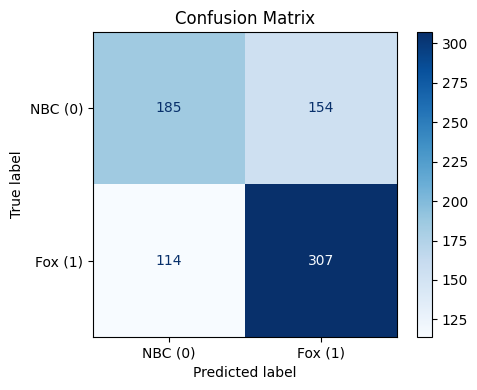

In [448]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["NBC (0)", "Fox (1)"], cmap="Blues", ax=ax
)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Top tokens per class
Logistic regression coefficients for each TF-IDF token. Positive coefficients push the prediction toward Fox; negative ones toward NBC. The magnitude is how strong the push is.

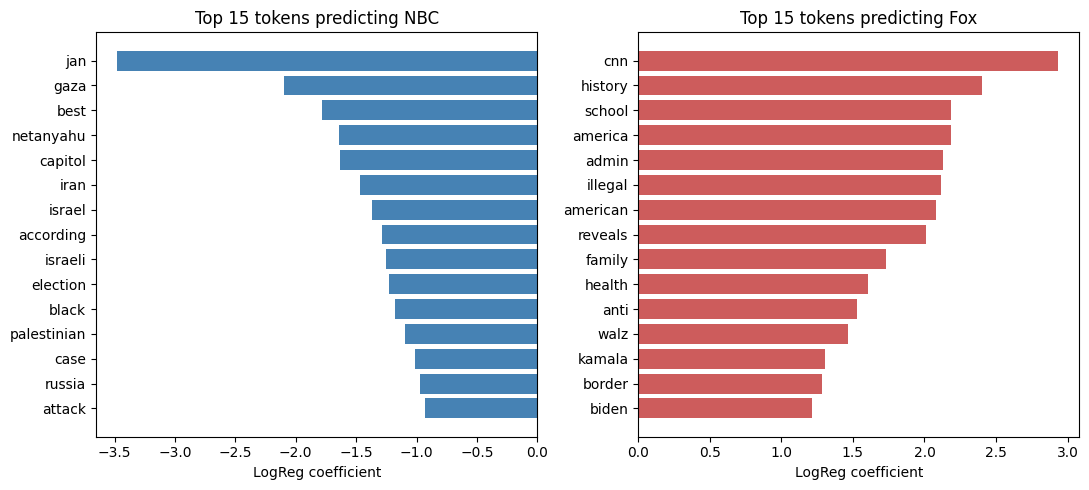

In [449]:
tokens = vectorizer.get_feature_names_out()
coefs = model.coef_[0]
order = np.argsort(coefs)
top_nbc_idx = order[:15]
top_fox_idx = order[-15:]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].barh(tokens[top_nbc_idx], coefs[top_nbc_idx], color="steelblue")
axes[0].set_title("Top 15 tokens predicting NBC")
axes[0].set_xlabel("LogReg coefficient")
axes[0].invert_yaxis()

axes[1].barh(tokens[top_fox_idx], coefs[top_fox_idx], color="indianred")
axes[1].set_title("Top 15 tokens predicting Fox")
axes[1].set_xlabel("LogReg coefficient")

plt.tight_layout()
plt.show()

### Predicted probability distribution
For each test headline, the model outputs P(Fox). If the two histograms (true Fox vs true NBC) overlap a lot, the model is uncertain. Cleanly separated peaks at 0 and 1 mean the model is confident.

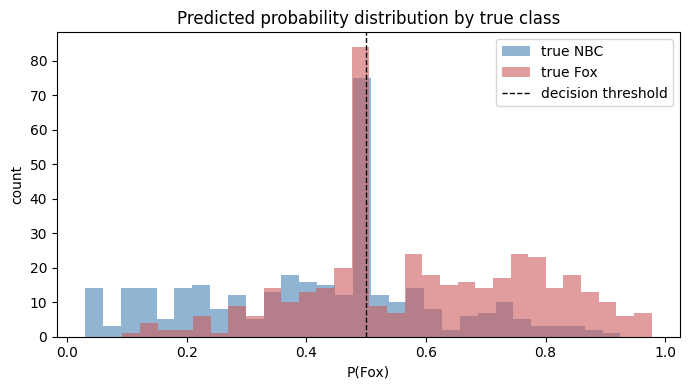

In [450]:
probs_fox = model.predict_proba(X_test_tfidf)[:, 1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(probs_fox[y_test == 0], bins=30, alpha=0.6, color="steelblue", label="true NBC")
ax.hist(probs_fox[y_test == 1], bins=30, alpha=0.6, color="indianred", label="true Fox")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="decision threshold")
ax.set_xlabel("P(Fox)")
ax.set_ylabel("count")
ax.set_title("Predicted probability distribution by true class")
ax.legend()
plt.tight_layout()
plt.show()

### ROC curve
Plots true positive rate against false positive rate as the classification threshold varies. AUC = 1 is perfect; AUC = 0.5 is random guessing.

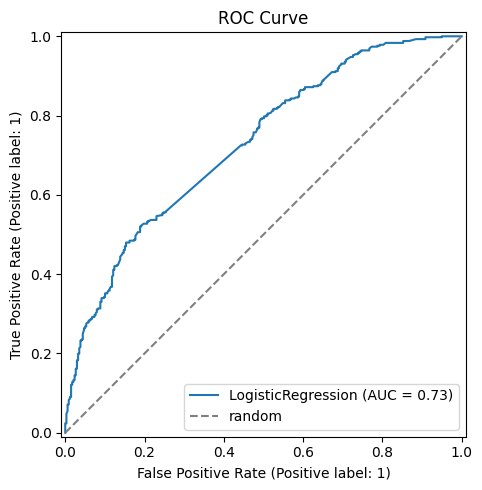

In [451]:
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_estimator(model, X_test_tfidf, y_test, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="random")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.show()